### Probability Density Function

In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("Preprocessed_Data_Cryptos.csv")
dataset.head()

,Year,Month,Day,Hour,Minute,Volume,Open,High,Low,Close,Price_Prediction
0,2012,1,1,10,1,0.0,4.58,4.58,4.58,4.58,Neutral
1,2012,1,1,10,2,0.0,4.58,4.58,4.58,4.58,Neutral
2,2012,1,1,10,3,0.0,4.58,4.58,4.58,4.58,Neutral
3,2012,1,1,10,4,0.0,4.58,4.58,4.58,4.58,Neutral
4,2012,1,1,10,5,0.0,4.58,4.58,4.58,4.58,Neutral


In [3]:
#Method-01, To check the Presence of Null values in Entire Dataset in Count, since having poor readability in Python
dataset.isnull().sum()

Year                0
Month               0
Day                 0
Hour                0
Minute              0
Volume              0
Open                0
High                0
Low                 0
Close               0
Price_Prediction    0
dtype: int64

In [4]:
import seaborn as sb

In [ ]:
#!pip install statsmodels

In [ ]:
"""
※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※
𝐂𝐫𝐞𝐚𝐭𝐢𝐧𝐠 𝐚 𝐅𝐮𝐧𝐜𝐭𝐢𝐨𝐧 ➖ 𝐠𝐞𝐭_𝐩𝐝𝐟_𝐩𝐫𝐨𝐛𝐚𝐛𝐢𝐥𝐢𝐭𝐲 ❪𝐃𝐚𝐭𝐚𝐬𝐞𝐭 Column Name 𝐚𝐬 𝐏𝐚𝐫𝐚𝐦𝐞𝐭𝐞𝐫❫
𝐏𝐮𝐫𝐩𝐨𝐬𝐞 : 𝐓𝐨 𝐀𝐮𝐭𝐨𝐦𝐚𝐭𝐞 𝐭𝐨 𝐤𝐧𝐨𝐰 𝐄𝐱𝐢𝐬𝐭𝐢𝐧𝐠 𝐏𝐞𝐫𝐜𝐞𝐧𝐭𝐚𝐠𝐞 𝐰𝐢𝐭𝐡𝐢𝐧 𝐭𝐡𝐞 𝐆𝐢𝐯𝐞𝐧 𝐒𝐭𝐚𝐫𝐭 𝐚𝐧𝐝 𝐄𝐧𝐝 𝐑𝐚𝐧𝐠𝐞
※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※
"""

def get_pdf_probability (columnNameOfDataset,startRange,endRange):

    """1. Importing Necessary Libraries"""

    #importing a module - pyplot from Library - matplotlib
    #pyplot is used for plotting Graphs
    from matplotlib import pyplot
    
    #importing a Class - norm from module - stats of Library - scipy 
    #norm helps to define the "Normal Distribution"
    from scipy.stats import norm 
    
    #importing Library - seaborn and assigning into a New Variable - sb
    #seaborn is used for plotting the "Probability Distribution"
    import seaborn as sb
    
    """2. Plotting the Data Distribution"""  
    
    #It Plots a "Histogram" of the dataset with "Kernel Density Estimation (KDE)"
    #Color of "Kernel Density Estimation (KDE)" will be "Blue"
    #Color of "Histogram Bars" will be "Yellow"
    data_distrubion = sb.distplot(columnNameOfDataset, kde=True, kde_kws={'color':'Blue'}, color='gold')
    pyplot.axvline(startRange,color='Green')
    pyplot.axvline(endRange,color='Red')
    
    """3. Calculating Mean and Standard Deviation for Sample (Dataset)"""

    #Creating a New variable - Sample and assigning dataset into it
    sample = columnNameOfDataset
    sample_Mean = sample.mean()
    sample_StandardDeviation = sample.std()
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_Mean, sample_StandardDeviation))

    """4. Defining the Normal Distribution"""
    
    # Normal distribution (dist) is calculated using the pre-calculated mean and standard deviation
    norm_dist = norm(sample_Mean, sample_StandardDeviation)
    
    """5. Calculating Probability for the Given Range"""
    
    # A list of values between startrange and endrange is created.
    values = [value for value in range(startRange,endRange)]    
    
    # The Probability Density Function (PDF) is Calculated for each value.
    probabilities = [norm_dist.pdf(value) for value in values] 
    
    # Summing all the Calculated Probabilities
    summed_probabilities = sum(probabilities)
    
    #Converting into Percentage and printing the same
    probability_Percentage = (summed_probabilities * 100)
    print(f"Percentage of Area between the given Range ({startRange},{endRange}) : {probability_Percentage:.2f} %")
    
    # Finally, the function Ends by returning the summed probability.
    return probability_Percentage

C:\Anaconda\envs\AI_ML\lib\site-packages\ipykernel_launcher.py:29: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751



Mean=375.328, Standard Deviation=4554.186
Percentage of Area between the given Range (50,70) : 0.17 %


0.17477712439435428

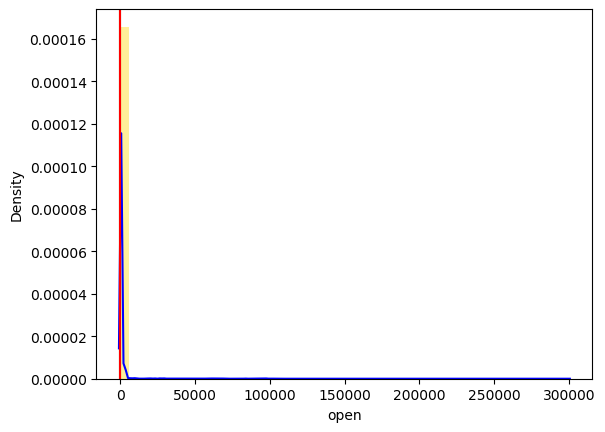

In [ ]:
#Calling the Created Function - get_pdf_probability (With Parameter(s) as input)

get_pdf_probability (dataset["Price_Prediction"],50,70)

### Empirical Cumulative Density Function (ECDF)

In [ ]:
#!pip install statsmodels

In [ ]:
"""
※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※
𝐂𝐫𝐞𝐚𝐭𝐢𝐧𝐠 𝐚 𝐅𝐮𝐧𝐜𝐭𝐢𝐨𝐧 ➖ get_ECDF ❪𝐃𝐚𝐭𝐚𝐬𝐞𝐭 Column Name 𝐚𝐬 𝐏𝐚𝐫𝐚𝐦𝐞𝐭𝐞𝐫❫
𝐏𝐮𝐫𝐩𝐨𝐬𝐞 : 𝐓𝐨 𝐀𝐮𝐭𝐨𝐦𝐚𝐭𝐞 𝐭𝐨 𝐤𝐧𝐨𝐰 Empirical Cumulative Density Function (ECDF) for 𝐆𝐢𝐯𝐞𝐧 𝐑𝐚𝐧𝐠𝐞
※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※
"""

def get_ECDF(columnNameOfDataset,range):

    # importing a FUnction - ECDF from Class - emperical_distributions from Module - distribution of Library - statsmodel 
    from statsmodels.distributions.empirical_distribution import ECDF

    # Calculating Empirical Cumulative Density Function (ECDF) for the Given Range
    ecdf = ECDF(columnNameOfDataset)
    calculated_ECDF = ecdf(range)

    #Converting into Percentage and printing the same
    ECDF_Percentage = (calculated_ECDF * 100)
    print(f"Percentage of Empirical Cumulative Density Function (ECDF) for the Given Range ({range}) : {ECDF_Percentage:.2f} %")
    
    return calculated_ECDF

In [ ]:
get_ECDF(dataset["open"],50)

Percentage of Empirical Cumulative Density Function (ECDF) for the Given Range (50) : 92.69 %


0.926853857459924

In [ ]:
"""
※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※
𝐂𝐫𝐞𝐚𝐭𝐢𝐧𝐠 𝐚 𝐅𝐮𝐧𝐜𝐭𝐢𝐨𝐧 ➖ stdNormalDistributionGraph ❪𝐃𝐚𝐭𝐚𝐬𝐞𝐭 Column Name 𝐚𝐬 𝐏𝐚𝐫𝐚𝐦𝐞𝐭𝐞𝐫❫
𝐏𝐮𝐫𝐩𝐨𝐬𝐞 : 𝐓𝐨 𝐀𝐮𝐭𝐨𝐦𝐚𝐭𝐞 𝐭𝐨 Convert Normal Distribution To Standard Normal Distribution for 𝐆𝐢𝐯𝐞𝐧 𝐑𝐚𝐧𝐠𝐞
※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※※
"""

def stdNormalDistributionGraph(columnNameOfDataset,range):
    
    """1. Importing Necessary Libraries"""

    #importing Library - seaborn and assigning into a New Variable - sb
    #seaborn is used for plotting the "Probability Distribution"
    import seaborn as sb
      
    """2. Calculating Mean and Standard Deviation for Sample (columnNameOfDataset)"""

    #Creating a New variable - Sample and assigning dataset into it
    sample = columnNameOfDataset
    sample_Mean = sample.mean()
    sample_StandardDeviation = sample.std()
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_Mean, sample_StandardDeviation))

    """3. Calculating Z-score for Sample (columnNameOfDataset)"""
    
    # A list of values for Sample (columnNameOfDataset) is created.
    values = [value for value in columnNameOfDataset]    
    
    # Here, Calculating Z-score for Sample (columnNameOfDataset)
    z_score = [((x-sample_Mean)/sample_StandardDeviation) for x in values]
    
    #Plotting Graph of Distance Plot Using Calculated Z-score
    sb.distplot(z_score,kde=True)

Mean=375.328, Standard Deviation=4554.186


C:\Anaconda\envs\AI_ML\lib\site-packages\ipykernel_launcher.py:33: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751



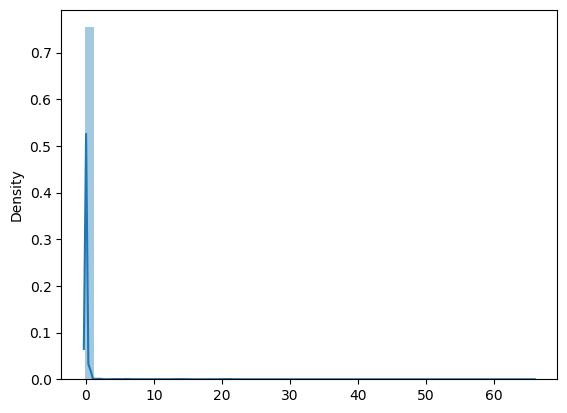

In [ ]:
stdNormalDistributionGraph(dataset["open"],60)